# Model merging

Two or more reference models can be combined into one, without needing any of the two original training datasets. The merged model will have indirectly learned from all datasets. The models to be merged don't even need to be of the same type, we can merge a `HBR` with a `BLR` model. The resulting model will have the type and configuration of the first model in the list. 


In [1]:
from pcntoolkit import load_fcon1000, HBR, NormativeModel, BLR
from pcntoolkit.util.plotter import plot_centiles_advanced
import numpy as np
import pcntoolkit

import pandas as pd
import logging
import warnings


# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

In [2]:
# Load the FCON data
data = load_fcon1000()
# Drop all but the first three response vars
data=data.sel({"response_vars":data.response_vars[:3]})

# Select a few sites at random for transfering
all_sites = data.unique_batch_effects['site']
selected_sites = np.random.choice(all_sites, len(all_sites)//2, replace=False)
print(selected_sites)

# Split by those sites
left_data,right_data  = data.batch_effects_split({"site":selected_sites},names=( "left", "right"))

# Split into train and test setss
left_train, left_test = left_data.train_test_split((0.8, 0.2))
right_train, right_test = right_data.train_test_split((0.8, 0.2))

['Milwaukee_b' 'Oulu' 'NewYork_a_ADHD' 'Cambridge_Buckner' 'NewYork_a'
 'Leiden_2180' 'Atlanta' 'PaloAlto' 'Leiden_2200' 'SaintLouis' 'Baltimore']


In [3]:
# Fit a model
#  Use default likelihood; Normal, with bspline in mu and sigma, and a random intercept for mu
left_model = NormativeModel(HBR(progressbar=False), save_dir ="../out/models/left_merge_model")
left_model.fit_predict(left_train, left_test);


c:\Users\kontsi\AppData\Local\anaconda3\envs\ptk-pu25\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


In [4]:
right_model = NormativeModel(BLR(heteroskedastic=True, warp_name="WarpSinhArcsinh"), save_dir ="../out/models/right_merge_model")
right_model.fit_predict(right_train, right_test);

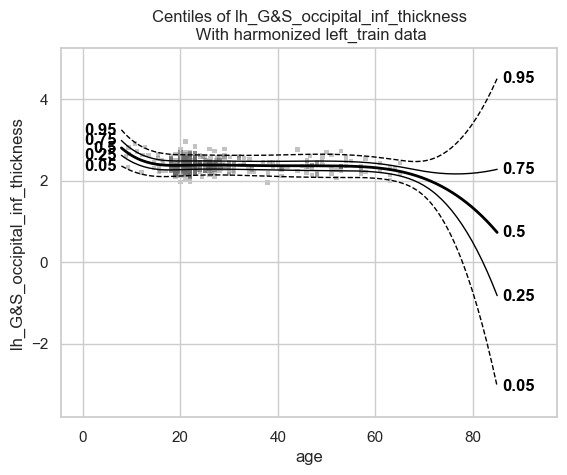

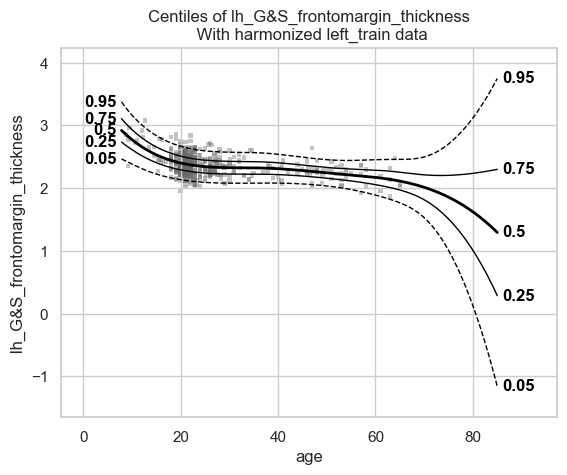

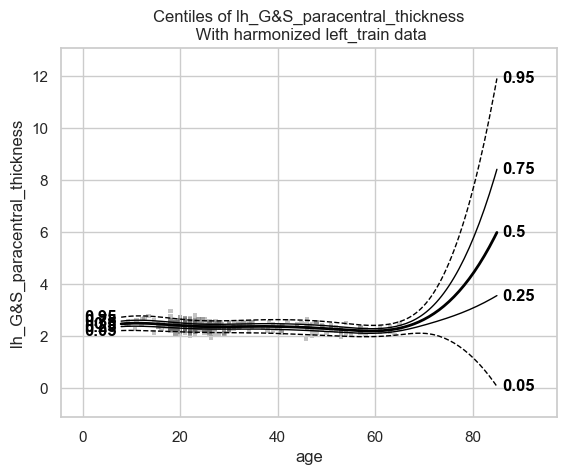

In [5]:
# Show the learned centiles
plot_centiles_advanced(left_model, scatter_data = left_train, covariate_range=(10, 80), show_other_data=True)

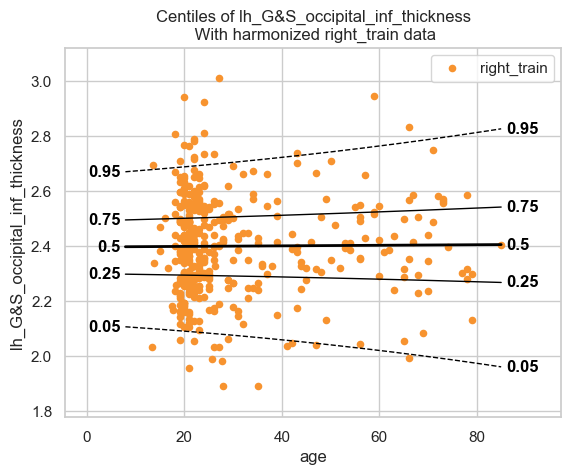

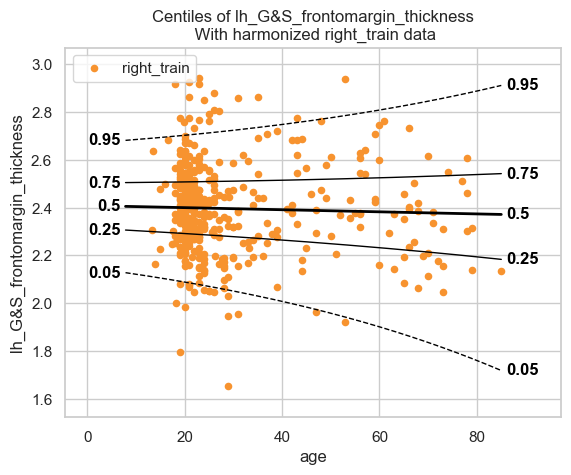

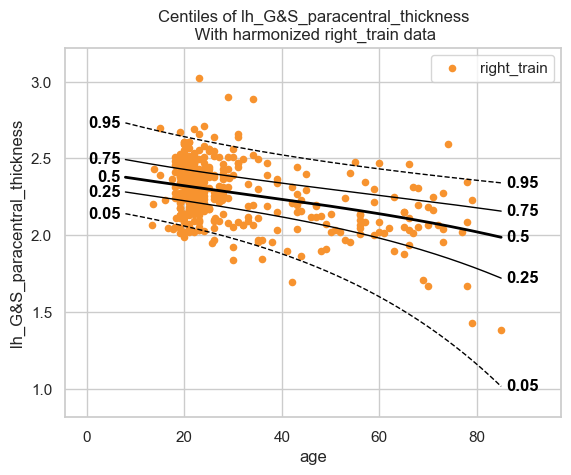

In [6]:
plot_centiles_advanced(right_model, scatter_data = right_train, covariate_range=(10, 80), show_other_data=True)

In [7]:
# Load the model from disk (could also use the model that we just fitted, but this just shows that you can easily load and transfer a model)
fitted_left_model = NormativeModel.load(left_model.save_dir)
fitted_right_model = NormativeModel.load(right_model.save_dir)

In [8]:
# Merging is super duper easy

# Merge the right model into the left model, will create a new HBR model. 
right_merged_into_left = NormativeModel.merge("../out/models/merge_right_into_left_model",[left_model, right_model]);

# If we would change the order of the models in the list, we would get a BLR model.

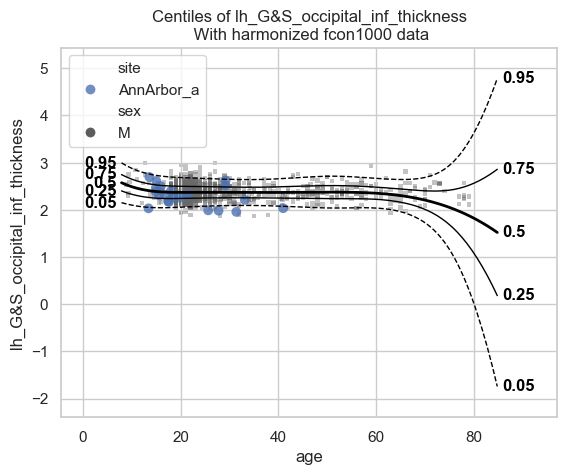

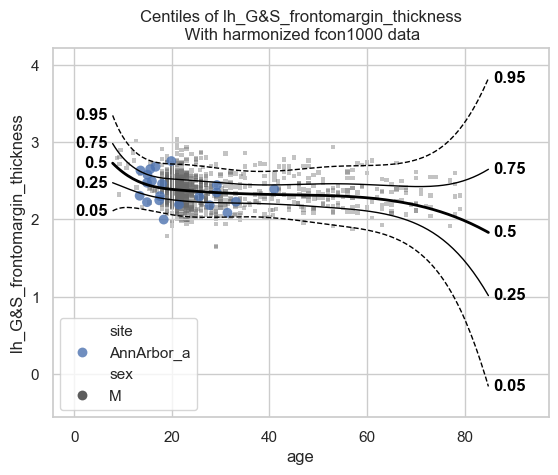

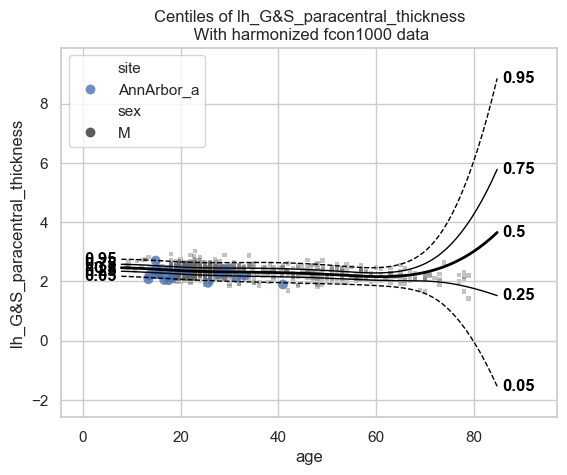

In [9]:
plot_centiles_advanced(right_merged_into_left, scatter_data = data, covariate_range=(10, 80), show_other_data=True)

The above plot show that the merged model is capable of making predictions on the entire source dataset, the one which we split into two to fit our models. The HBR model has learned the group effects of all the sites. 